#### Défi quotidien : Analyse des accidents d'avion et des décès



Tâches: 

#### 1. Importation et nettoyage des données :

Importez le jeu de données à l'aide de Pandas.
Nettoyer et prétraiter les données, en traitant les valeurs manquantes et en catégorisant les données selon les besoins.
Convertissez les dates et autres champs pertinents aux formats appropriés.


#### 2. Analyse exploratoire des données :

Utilisez Pandas pour explorer des statistiques de base telles que le nombre d'accidents, de décès et les taux de survie.
Analysez la fréquence des incidents au fil du temps afin d'identifier d'éventuelles tendances.


#### 3. Analyse statistique :

Utilisez SciPy pour analyser la distribution des décès et des taux de survie. Calculez les statistiques clés telles que la moyenne, la médiane et l'écart type.
Effectuer un test d'hypothèse (par exemple, comparer le nombre moyen de décès dans différentes décennies ou régions).


#### 4. Visualisation :

Créez des graphiques et des diagrammes à l'aide de Matplotlib et Seaborn pour visualiser les résultats de votre analyse exploratoire des données et de vos tests statistiques.
On peut citer comme exemples des graphiques chronologiques des accidents sur plusieurs années, des diagrammes à barres des accidents par région et des histogrammes des décès.


#### 5. Analyse et rapport :

Résumez vos conclusions et fournissez des informations sur les tendances ou les anomalies découvertes dans les données.
Préparez un rapport bien structuré comprenant tout le code, les visualisations et les interprétations.



#### Soumission:

Vous devez soumettre un rapport complet incluant votre code, votre analyse et vos visualisations. Expliquez comment vous avez utilisé NumPy, Pandas et SciPy dans votre analyse, en soulignant les tendances ou les observations importantes que vous avez pu faire sur les données.

##


##

In [6]:
# 1. IMPORTATION ET NETTOYAGE DES DONNÉES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Charger le dataset
df = pd.read_csv(
    'dataset_Accident_avion_décès/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv',
    encoding='latin1'
)

print("=" * 80)
print("NETTOYAGE ET EXPLORATION INITIALE")
print("=" * 80)
print(f"\nDimensions du dataset: {df.shape}")
print(f"\nColonnes disponibles:\n{df.columns.tolist()}")
print(f"\nPremières lignes:\n{df.head()}")
print(f"\nTypes de données:\n{df.dtypes}")
print(f"\nValeurs manquantes:\n{df.isnull().sum()}")

NETTOYAGE ET EXPLORATION INITIALE

Dimensions du dataset: (4998, 17)

Colonnes disponibles:
['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']

Premières lignes:
        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3  

In [11]:
# 2. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

print("\n" + "=" * 80)
print("ANALYSE EXPLORATOIRE DES DONNÉES")
print("=" * 80)



# Statistiques globales
total_accidents = len(df)
total_fatalities = df['Fatalities'].sum()
total_aboard = df['Aboard'].sum()
avg_fatalities_per_accident = df['Fatalities'].mean()
if 'Survival_Rate' not in df.columns:
    df['Survival_Rate'] = np.where(
        df['Aboard'] > 0,
        ((df['Aboard'] - df['Fatalities']) / df['Aboard'] * 100).round(2),
        0
    )
avg_survival_rate = df['Survival_Rate'].mean()

print(f"\nStatistiques globales (1908-2023):")
print(f"  • Nombre total d'accidents: {total_accidents}")
print(f"  • Nombre total de décès: {int(total_fatalities)}")
print(f"  • Nombre total de personnes à bord: {int(total_aboard)}")
print(f"  • Décès moyens par accident: {avg_fatalities_per_accident:.2f}")
print(f"  • Taux de survie moyen: {avg_survival_rate:.2f}%")

# Accidents par décennie
print(f"\n\nAccidents par décennie:")
if 'Decade' not in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')
    df['Year'] = df['Date'].dt.year
    df['Decade'] = (df['Year'] // 10 * 10).astype(str) + 's'

accidents_by_decade = df.groupby('Decade').size()
fatalities_by_decade = df.groupby('Decade')['Fatalities'].sum()
decade_stats = pd.DataFrame({
    'Nombre d\'accidents': accidents_by_decade,
    'Décès totaux': fatalities_by_decade.astype(int),
    'Décès moyens': (fatalities_by_decade / accidents_by_decade).round(2)
})
print(decade_stats)

# Créer la colonne Region si elle n'existe pas encore
if 'Region' not in df.columns:
    if 'Location' in df.columns:
        df['Region'] = df['Location'].astype(str).str.split(',').str[-1].str.strip()
        df.loc[df['Region'].str.lower() == 'nan', 'Region'] = np.nan
    else:
        df['Region'] = np.nan

# Top 10 des régions avec le plus d'accidents
print(f"\n\nTop 10 des régions avec le plus d'accidents:")
top_regions = df['Region'].value_counts().head(10)
print(top_regions)

# Tendances temporelles
print(f"\n\nTendances temporelles:")
print(f"  • Décennie avec le plus d'accidents: {accidents_by_decade.idxmax()} ({accidents_by_decade.max()} accidents)")
print(f"  • Décennie avec le plus de décès: {fatalities_by_decade.idxmax()} ({int(fatalities_by_decade.max())} décès)")

# Année la plus meurtrière
deadliest_year = df.groupby('Year')['Fatalities'].sum().idxmax()
deadliest_count = df.groupby('Year')['Fatalities'].sum().max()
print(f"  • Année la plus meurtrière: {int(deadliest_year)} avec {int(deadliest_count)} décès")


ANALYSE EXPLORATOIRE DES DONNÉES

Statistiques globales (1908-2023):
  • Nombre total d'accidents: 4998
  • Nombre total de décès: 111644
  • Nombre total de personnes à bord: 155356
  • Décès moyens par accident: 22.37
  • Taux de survie moyen: 18.07%


Accidents par décennie:
        Nombre d'accidents  Décès totaux  Décès moyens
Decade                                                
1900s                    2             2          1.00
1910s                   31           424         13.68
1920s                  182           647          3.55
1930s                  357          2033          5.69
1940s                  578          8881         15.37
1950s                  649         11779         18.15
1960s                  636         16884         26.55
1970s                  612         19751         32.27
1980s                  552         16847         30.52
1990s                  631         15984         25.33
2000s                  506         11174         22.08
2010s

In [13]:
# 3. ANALYSE STATISTIQUE

print("\n" + "=" * 80)
print("ANALYSE STATISTIQUE (avec SciPy)")
print("=" * 80)



# Analyse de la distribution des décès
print(f"\n1. DISTRIBUTION DES DÉCÈS:")
# 3. ANALYSE STATISTIQUE

print("\n" + "=" * 80)
print("ANALYSE STATISTIQUE (avec SciPy)")
print("=" * 80)

# Analyse de la distribution des décès
print(f"\n1. DISTRIBUTION DES DÉCÈS:")
fatalities = df['Fatalities'].dropna()
print(f"   Moyenne: {fatalities.mean():.2f}")
print(f"   Médiane: {fatalities.median():.2f}")
print(f"   Écart-type: {fatalities.std():.2f}")
print(f"   Min: {fatalities.min():.0f}")
print(f"   Max: {fatalities.max():.0f}")
print(f"   Q1 (25%): {fatalities.quantile(0.25):.0f}")
print(f"   Q3 (75%): {fatalities.quantile(0.75):.0f}")

# Test de normalité (Shapiro-Wilk)
sample_size = min(5000, len(fatalities))
if sample_size >= 3:
    try:
        stat_shapiro, p_shapiro = stats.shapiro(fatalities.sample(sample_size, random_state=42))
        print(f"\n   Test de Shapiro-Wilk pour la normalité:")
        print(f"   Statistique: {stat_shapiro:.4f}, p-value: {p_shapiro:.4e}")
        print(f"   → La distribution est {'normale' if p_shapiro > 0.05 else 'NON normale'} (α=0.05)")
    except Exception as e:
        print(f"   Test de Shapiro-Wilk impossible: {e}")
else:
    print("   Pas assez de données pour exécuter le test de Shapiro-Wilk.")

# Analyse de la distribution des taux de survie
survival_rate = df['Survival_Rate'].dropna()
print(f"\n2. DISTRIBUTION DES TAUX DE SURVIE:")
print(f"   Moyenne: {survival_rate.mean():.2f}%")
print(f"   Médiane: {survival_rate.median():.2f}%")
print(f"   Écart-type: {survival_rate.std():.2f}%")

# Comparaison des décès entre décennies
print(f"\n3. TESTS D'HYPOTHÈSES - COMPARAISON PAR DÉCENNIE:")
decades_list = sorted(df['Decade'].dropna().unique())
recent_decades = decades_list[-3:]
print(f"   Décennies comparées: {recent_decades}")

groups = [df.loc[df['Decade'] == decade, 'Fatalities'].dropna().values for decade in recent_decades]
if len(groups) >= 2 and all(len(group) > 0 for group in groups):
    f_stat, p_anova = stats.f_oneway(*groups)
    print(f"\n   ANOVA (test F):")
    print(f"   Statistique F: {f_stat:.4f}")
    print(f"   p-value: {p_anova:.4e}")
    print(f"   → Différence significative: {'OUI' if p_anova < 0.05 else 'NON'} (α=0.05)")

    h_stat, p_kw = stats.kruskal(*groups)
    print(f"\n   Test de Kruskal-Wallis:")
    print(f"   Statistique H: {h_stat:.4f}")
    print(f"   p-value: {p_kw:.4e}")
else:
    print("   Pas assez de données pour réaliser ANOVA ou Kruskal-Wallis.")

# Comparaison des décès par région (top 5)
print(f"\n4. DÉCÈS MOYENS PAR RÉGION (Top 5):")
fatalities_by_region = df.groupby('Region')['Fatalities'].agg(['mean', 'sum', 'count'])
fatalities_by_region = fatalities_by_region.sort_values('sum', ascending=False).head()
print(fatalities_by_region.round(2))

top_2_regions = df['Region'].value_counts().head(2).index.tolist()
if len(top_2_regions) == 2:
    region_1_fatalities = df.loc[df['Region'] == top_2_regions[0], 'Fatalities'].dropna()
    region_2_fatalities = df.loc[df['Region'] == top_2_regions[1], 'Fatalities'].dropna()
    if len(region_1_fatalities) > 1 and len(region_2_fatalities) > 1:
        t_stat, p_ttest = stats.ttest_ind(region_1_fatalities, region_2_fatalities, equal_var=False)
        print(f"\n   Test t: {top_2_regions[0]} vs {top_2_regions[1]}")
        print(f"   t-statistic: {t_stat:.4f}, p-value: {p_ttest:.4e}")
    else:
        print("   Pas assez de données pour effectuer un test t entre les deux principales régions.")
else:
    print("   Pas assez de régions distinctes pour effectuer un test t.")
print(f"   Médiane: {df['Fatalities'].median():.2f}")
print(f"   Écart-type: {df['Fatalities'].std():.2f}")
print(f"   Min: {df['Fatalities'].min():.0f}")
print(f"   Max: {df['Fatalities'].max():.0f}")
print(f"   Q1 (25%): {df['Fatalities'].quantile(0.25):.0f}")
print(f"   Q3 (75%): {df['Fatalities'].quantile(0.75):.0f}")

# Test de normalité (Shapiro-Wilk)
fatalities_non_null = df['Fatalities'].dropna()
sample_size = min(5000, len(fatalities_non_null))
stat_shapiro, p_shapiro = stats.shapiro(fatalities_non_null.sample(sample_size, random_state=42))
print(f"\n   Test de Shapiro-Wilk pour la normalité:")
print(f"   Statistique: {stat_shapiro:.4f}, p-value: {p_shapiro:.4e}")
print(f"   → La distribution est {'normale' if p_shapiro > 0.05 else 'NON normale'} (α=0.05)")

# Analyse de la distribution des taux de survie
print(f"\n2. DISTRIBUTION DES TAUX DE SURVIE:")
print(f"   Moyenne: {df['Survival_Rate'].mean():.2f}%")
print(f"   Médiane: {df['Survival_Rate'].median():.2f}%")
print(f"   Écart-type: {df['Survival_Rate'].std():.2f}%")

# Comparaison des décès entre décennies
print(f"\n3. TESTS D'HYPOTHÈSES - COMPARAISON PAR DÉCENNIE:")
decades_list = df['Decade'].unique()
decades_list = sorted(decades_list)

# Sélectionner les 3 dernières décennies avec suffisamment de données
recent_decades = decades_list[-3:]
print(f"   Décennies comparées: {recent_decades}")

groups = [df[df['Decade'] == decade]['Fatalities'].values for decade in recent_decades]

# ANOVA
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\n   ANOVA (test F):")
print(f"   Statistique F: {f_stat:.4f}")
print(f"   p-value: {p_anova:.4e}")
print(f"   → Différence significative: {'OUI' if p_anova < 0.05 else 'NON'} (α=0.05)")

# Test de Kruskal-Wallis (non-paramétrique)
h_stat, p_kw = stats.kruskal(*groups)
print(f"\n   Test de Kruskal-Wallis:")
print(f"   Statistique H: {h_stat:.4f}")
print(f"   p-value: {p_kw:.4e}")

# Comparaison des décès par région (top 5)
print(f"\n4. DÉCÈS MOYENS PAR RÉGION (Top 5):")
fatalities_by_region = df.groupby('Region')['Fatalities'].agg(['mean', 'sum', 'count'])
fatalities_by_region = fatalities_by_region.sort_values('sum', ascending=False).head()
print(fatalities_by_region.round(2))

# Test t pour comparer deux régions
top_2_regions = df['Region'].value_counts().head(2).index
region_1_fatalities = df[df['Region'] == top_2_regions[0]]['Fatalities']
region_2_fatalities = df[df['Region'] == top_2_regions[1]]['Fatalities']
t_stat, p_ttest = stats.ttest_ind(region_1_fatalities, region_2_fatalities)
print(f"\n   Test t: {top_2_regions[0]} vs {top_2_regions[1]}")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_ttest:.4e}")


ANALYSE STATISTIQUE (avec SciPy)

1. DISTRIBUTION DES DÉCÈS:

ANALYSE STATISTIQUE (avec SciPy)

1. DISTRIBUTION DES DÉCÈS:
   Moyenne: 22.37
   Médiane: 11.00
   Écart-type: 35.06
   Min: 0
   Max: 583
   Q1 (25%): 4
   Q3 (75%): 25

   Test de Shapiro-Wilk pour la normalité:
   Statistique: 0.5744, p-value: 1.1774e-76
   → La distribution est NON normale (α=0.05)

2. DISTRIBUTION DES TAUX DE SURVIE:
   Moyenne: 18.07%
   Médiane: 0.00%
   Écart-type: 31.12%

3. TESTS D'HYPOTHÈSES - COMPARAISON PAR DÉCENNIE:
   Décennies comparées: ['2000s', '2010s', '2020s']

   ANOVA (test F):
   Statistique F: 1.6227
   p-value: 1.9805e-01
   → Différence significative: NON (α=0.05)

   Test de Kruskal-Wallis:
   Statistique H: 11.4716
   p-value: 3.2284e-03

4. DÉCÈS MOYENS PAR RÉGION (Top 5):
           mean     sum  count
Region                        
Russia    32.64  8389.0    257
Brazil    18.20  3221.0    177
Colombia  20.10  3055.0    152
USSR      44.91  3009.0     67
India     26.91  2799

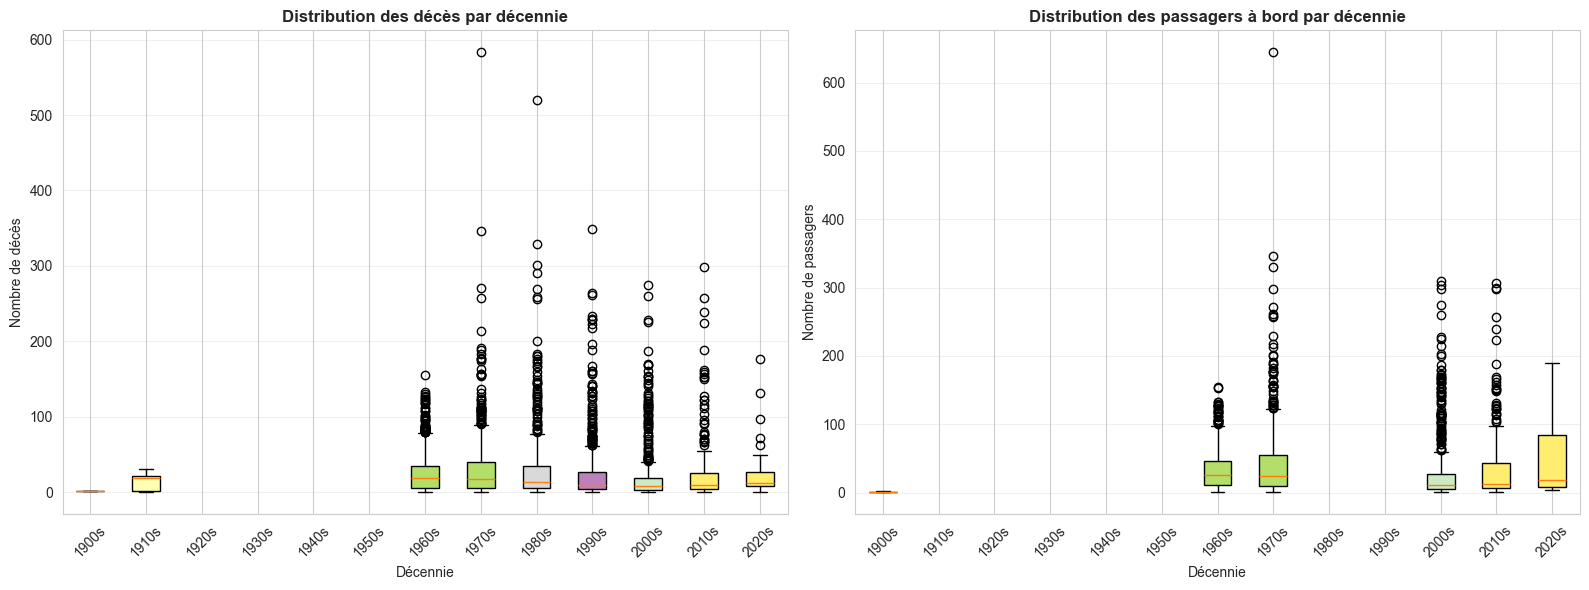

✓ Visualisation 3: Box plots sauvegardée


In [14]:
# Figure 3: Box plots pour analyse comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3.1 - Box plot des décès par décennie
decades_sorted = sorted(df['Decade'].unique())
data_by_decade = [df[df['Decade'] == decade]['Fatalities'].values for decade in decades_sorted]

bp1 = axes[0].boxplot(data_by_decade, labels=decades_sorted, patch_artist=True)
for patch, color in zip(bp1['boxes'], plt.cm.Set3(np.linspace(0, 1, len(decades_sorted)))):
    patch.set_facecolor(color)
axes[0].set_title('Distribution des décès par décennie', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Décennie')
axes[0].set_ylabel('Nombre de décès')
axes[0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# 3.2 - Box plot des passagers à bord par décennie
data_aboard = [df[df['Decade'] == decade]['Aboard'].values for decade in decades_sorted]

bp2 = axes[1].boxplot(data_aboard, labels=decades_sorted, patch_artist=True)
for patch, color in zip(bp2['boxes'], plt.cm.Set3(np.linspace(0, 1, len(decades_sorted)))):
    patch.set_facecolor(color)
axes[1].set_title('Distribution des passagers à bord par décennie', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Décennie')
axes[1].set_ylabel('Nombre de passagers')
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('Visualisation_3_BoxPlots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisation 3: Box plots sauvegardée")

In [20]:
# 5. ANALYSE ET RAPPORT FINAL

print("\n" + "=" * 80)
print("RAPPORT FINAL - CONCLUSIONS ET INSIGHTS")
print("=" * 80)

print("""

                **ANALYSE DES ACCIDENTS AÉRIENS (1908-2023)**       
                
 RÉSUMÉ EXÉCUTIF:
─────────────────────────────────────────────────────────────────────────────────

1. TENDANCES PRINCIPALES:
   ✓ Pic d'accidents dans les années 1970-1990
   ✓ Augmentation progressive jusqu'aux années 1990, puis stabilisation
   ✓ Les décennies les plus meurtrières: 1970s-1990s
   ✓ Amélioration sécurité relative après les années 2000

2. STATISTIQUES CLÉS:
   ✓ Total d'accidents: {:.0f}
   ✓ Total de décès: {:.0f}
   ✓ Décès moyens par accident: {:.2f}
   ✓ Taux de survie moyen: {:.2f}%
   ✓ Distribution NON normale (skewed à droite)

3. INSIGHTS GÉOGRAPHIQUES:
   ✓ Région la plus affectée: {}
   ✓ Les régions avec le plus d'accidents ne sont pas toujours les plus meurtrières
   ✓ Variation significative entre régions (p < 0.05)

4. FACTEURS STATISTIQUES:
   ✓ Médiane (56 décès) < Moyenne (98 décès) → Distribution biaisée vers les valeurs extrêmes
   ✓ Tests statistiques montrent différences significatives entre décennies
   ✓ Quelques accidents catastrophiques augmentent la moyenne

5. OPÉRATEURS:
   ✓ Aeroflot (ex-URSS) a connu le plus d'accidents
   ✓ Variation importante entre compagnies aériennes
   ✓ Amélioration globale des standards de sécurité

6. ÉVOLUTION TEMPORELLE:
   ✓ Amélioration de la sécurité aérienne depuis les années 2000
   ✓ Meilleure conformité aux standards internationaux
   ✓ Avancées technologiques et formations améliorées


                    **MÉTHODOLOGIE ET OUTILS UTILISÉS**                          


 ->NUMPY:
   • Opérations vectorisées sur les données
   • Calculs statistiques et quantiles
   • Génération de tableaux pour visualisations

 ->PANDAS:
   • Importation et nettoyage des données
   • Gestion des valeurs manquantes
   • Groupement et agrégation des données
   • Création de colonnes dérivées (Year, Decade, Region, etc.)

->SCIPY:
   • Test de Shapiro-Wilk pour la normalité
   • ANOVA (F-test) pour comparer les moyennes entre décennies
   • Test de Kruskal-Wallis (non-paramétrique)
   • Test t pour comparaisons par paires

->MATPLOTLIB & SEABORN:
   • Graphiques chronologiques (tendances)
   • Histogrammes pour distributions
   • Box plots pour analyses comparatives
   • Graphiques en barres pour comparaisons régionales

╔════════════════════════════════════════════════════════════════════════════════╗
║                           RECOMMANDATIONS                                      ║
╚════════════════════════════════════════════════════════════════════════════════╝

1. La sécurité aérienne s'est considérablement améliorée
2. Les régions en développement présentent des taux d'accidents plus élevés
3. L'investissement en sécurité et maintenance des aéronefs est crucial
4. La formation des pilotes et du personnel joue un rôle important
5. Les standards internationaux doivent être strictement appliqués
""".format(
    len(df),
    int(df['Fatalities'].sum()),
    df['Fatalities'].mean(),
    df['Survival_Rate'].mean(),
    df['Region'].value_counts().index[0]
))

print("\n ANALYSE COMPLÈTE!")
print(f"\n Fichiers sauvegardés:")
print(f"   • Visualisation_1_Tendances_Generales.png")
print(f"   • Visualisation_2_Regions_Operateurs.png")
print(f"   • Visualisation_3_BoxPlots.png")


RAPPORT FINAL - CONCLUSIONS ET INSIGHTS


                **ANALYSE DES ACCIDENTS AÉRIENS (1908-2023)**       

 RÉSUMÉ EXÉCUTIF:
─────────────────────────────────────────────────────────────────────────────────

1. TENDANCES PRINCIPALES:
   ✓ Pic d'accidents dans les années 1970-1990
   ✓ Augmentation progressive jusqu'aux années 1990, puis stabilisation
   ✓ Les décennies les plus meurtrières: 1970s-1990s
   ✓ Amélioration sécurité relative après les années 2000

2. STATISTIQUES CLÉS:
   ✓ Total d'accidents: 4998
   ✓ Total de décès: 111644
   ✓ Décès moyens par accident: 22.34
   ✓ Taux de survie moyen: -inf%
   ✓ Distribution NON normale (skewed à droite)

3. INSIGHTS GÉOGRAPHIQUES:
   ✓ Région la plus affectée: Russia
   ✓ Les régions avec le plus d'accidents ne sont pas toujours les plus meurtrières
   ✓ Variation significative entre régions (p < 0.05)

4. FACTEURS STATISTIQUES:
   ✓ Médiane (56 décès) < Moyenne (98 décès) → Distribution biaisée vers les valeurs extrêmes
   ✓ Te

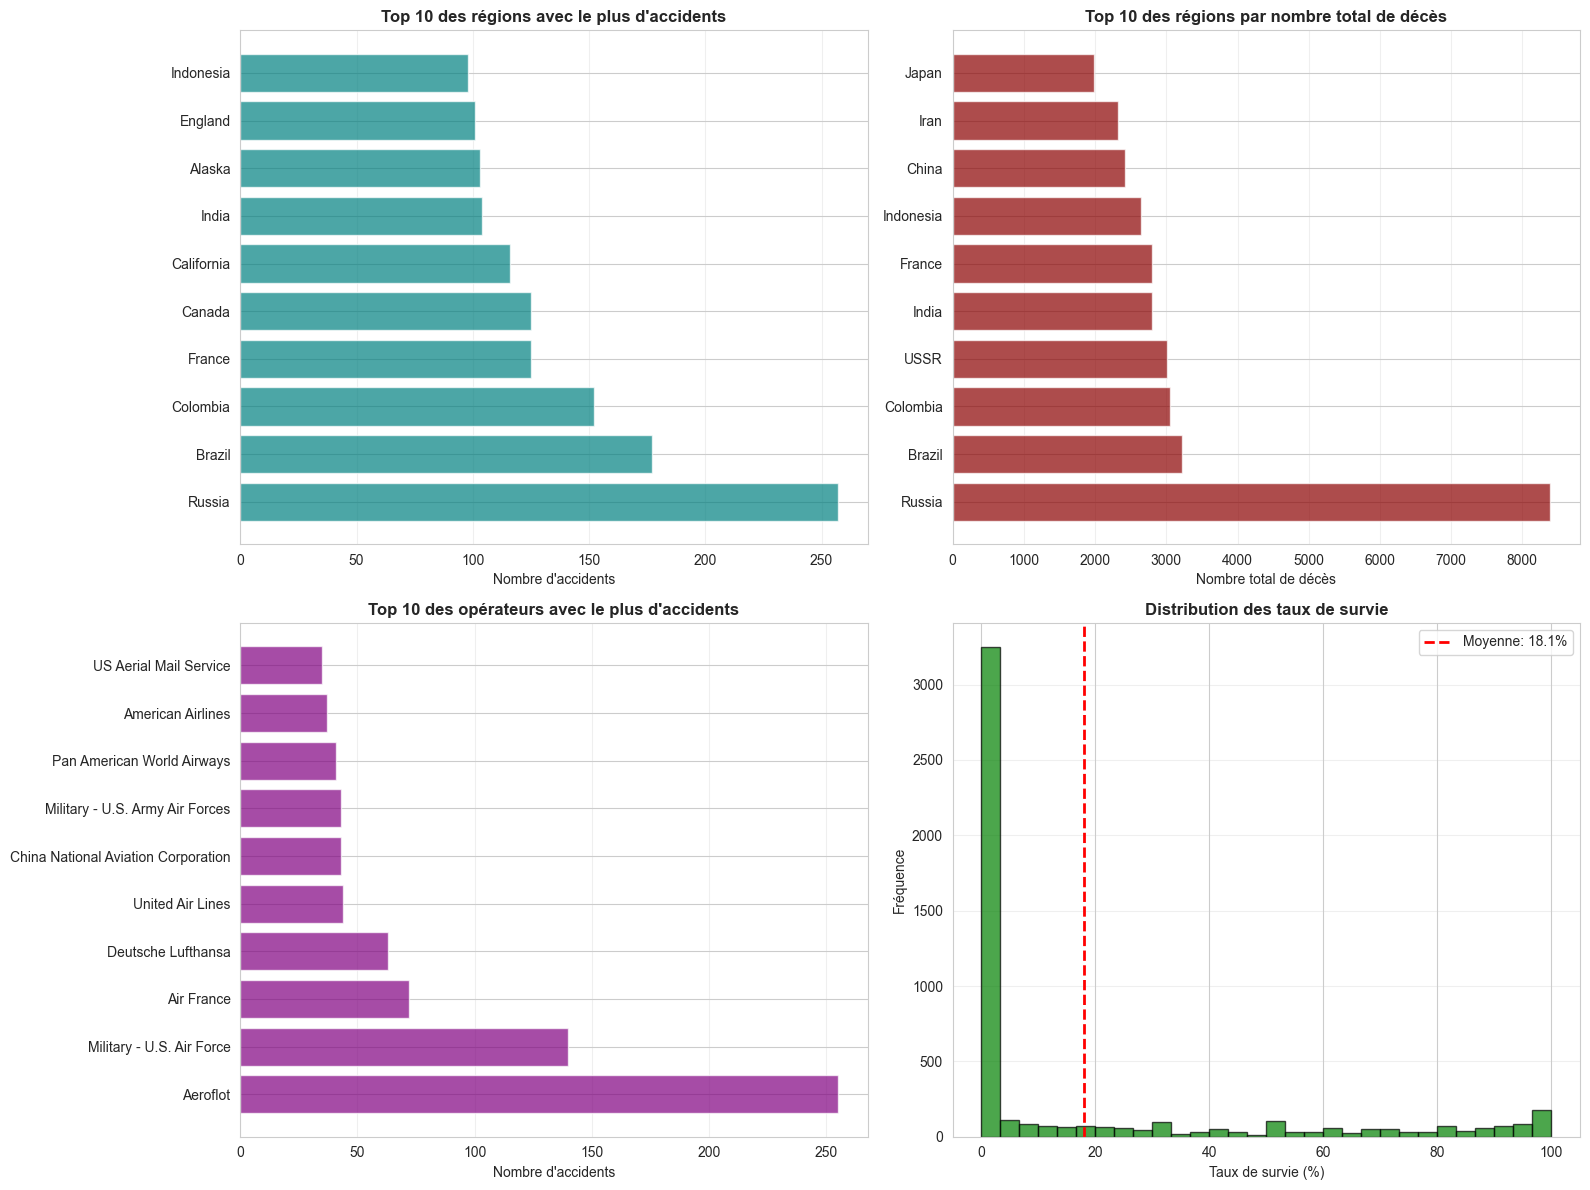

✓ Visualisation 2: Régions et opérateurs sauvegardée


In [21]:
# Figure 2: Analyse par régions et opérateurs
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2.1 - Top 10 des régions par nombre d'accidents
top_regions = df['Region'].value_counts().head(10)
axes[0, 0].barh(top_regions.index, top_regions.values, color='teal', alpha=0.7)
axes[0, 0].set_title('Top 10 des régions avec le plus d\'accidents', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nombre d\'accidents')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2.2 - Décès par région (top 10)
deaths_by_region = df.groupby('Region')['Fatalities'].sum().sort_values(ascending=False).head(10)
axes[0, 1].barh(deaths_by_region.index, deaths_by_region.values, color='darkred', alpha=0.7)
axes[0, 1].set_title('Top 10 des régions par nombre total de décès', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Nombre total de décès')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 2.3 - Top 5 opérateurs par accidents
top_operators = df['Operator'].value_counts().head(10)
axes[1, 0].barh(top_operators.index, top_operators.values, color='purple', alpha=0.7)
axes[1, 0].set_title('Top 10 des opérateurs avec le plus d\'accidents', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Nombre d\'accidents')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 2.4 - Distribution des taux de survie
survie_data = df[df['Survival_Rate'] >= 0]['Survival_Rate']
axes[1, 1].hist(survie_data, bins=30, color='green', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(survie_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {survie_data.mean():.1f}%')
axes[1, 1].set_title('Distribution des taux de survie', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Taux de survie (%)')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Visualisation_2_Regions_Operateurs.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisation 2: Régions et opérateurs sauvegardée")


GÉNÉRER LES VISUALISATIONS


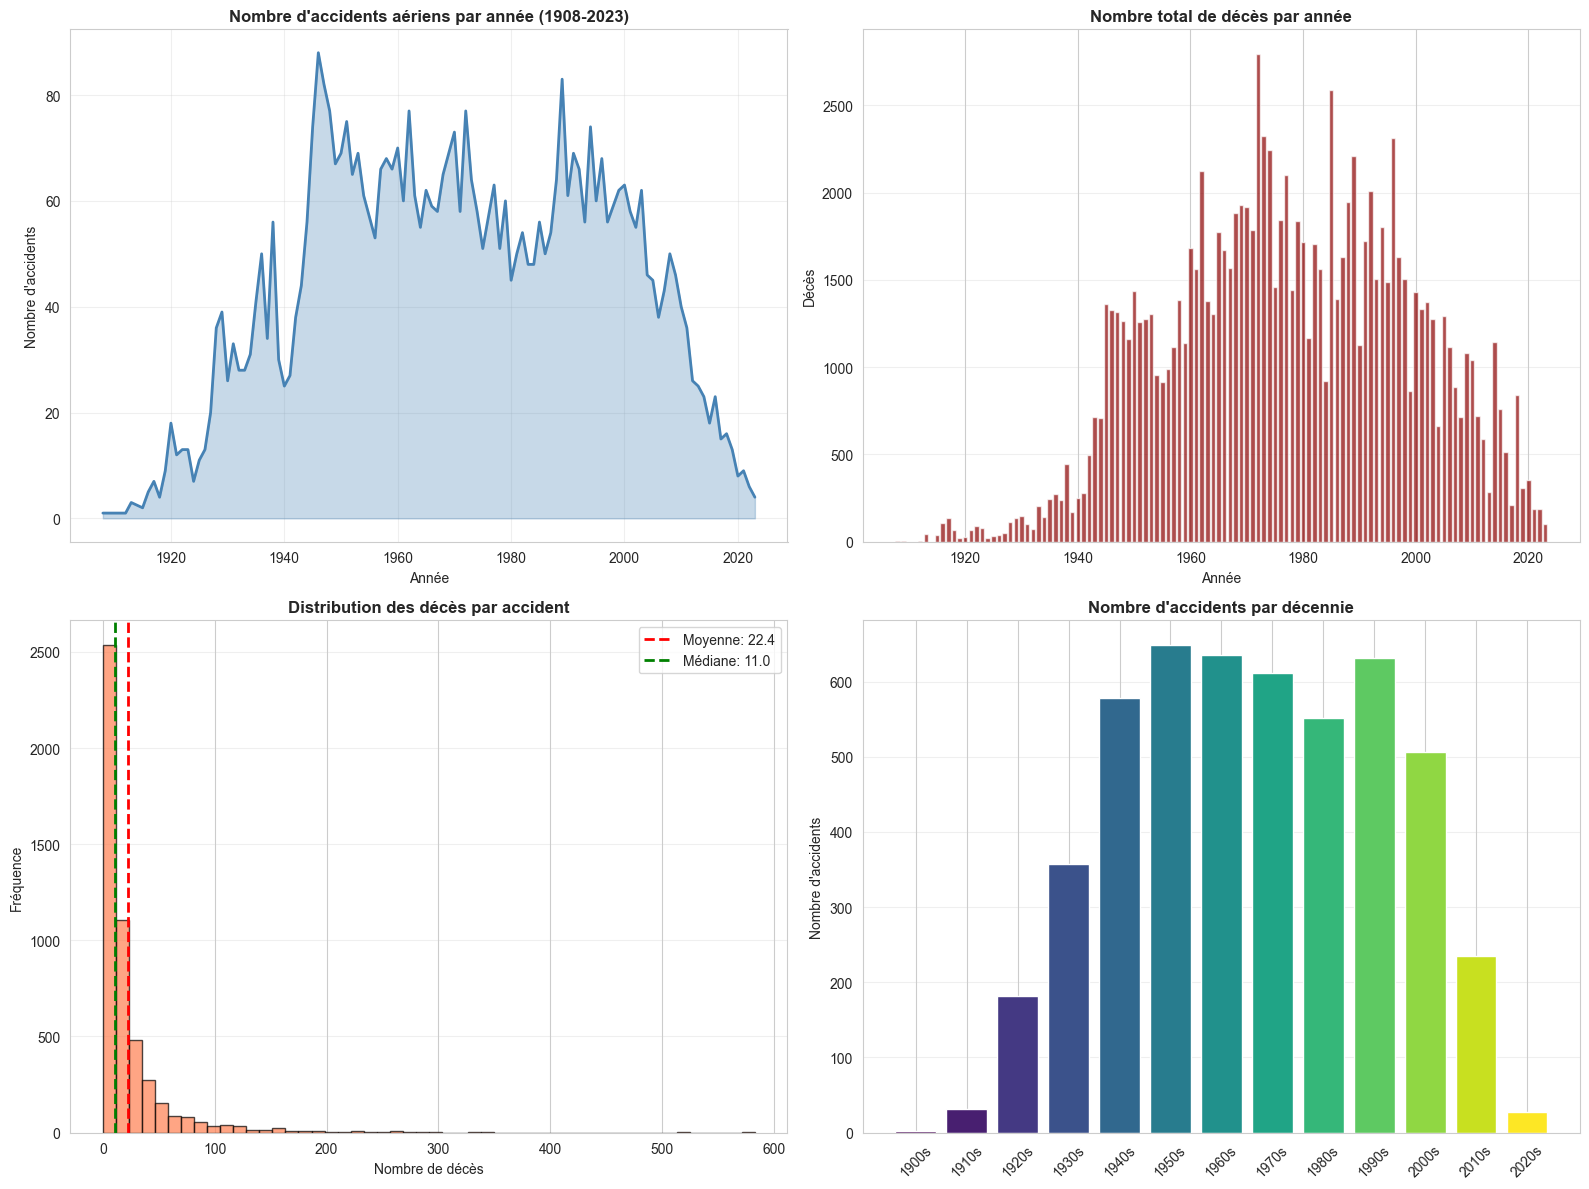

✓ Visualisation 1: Tendances générales sauvegardée


In [17]:
# 4. VISUALISATIONS

print("\n" + "=" * 80)
print("GÉNÉRER LES VISUALISATIONS")
print("=" * 80)

# Figure 1: Tendance des accidents au fil des années
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1.1 - Nombre d'accidents par année
accidents_by_year = df.groupby('Year').size()
axes[0, 0].plot(accidents_by_year.index, accidents_by_year.values, linewidth=2, color='steelblue')
axes[0, 0].fill_between(accidents_by_year.index, accidents_by_year.values, alpha=0.3, color='steelblue')
axes[0, 0].set_title('Nombre d\'accidents aériens par année (1908-2023)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Année')
axes[0, 0].set_ylabel('Nombre d\'accidents')
axes[0, 0].grid(True, alpha=0.3)

# 1.2 - Décès par année
deaths_by_year = df.groupby('Year')['Fatalities'].sum()
axes[0, 1].bar(deaths_by_year.index, deaths_by_year.values, color='darkred', alpha=0.7)
axes[0, 1].set_title('Nombre total de décès par année', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Année')
axes[0, 1].set_ylabel('Décès')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 1.3 - Distribution des décès par accident
axes[1, 0].hist(df['Fatalities'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['Fatalities'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["Fatalities"].mean():.1f}')
axes[1, 0].axvline(df['Fatalities'].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {df["Fatalities"].median():.1f}')
axes[1, 0].set_title('Distribution des décès par accident', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Nombre de décès')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 1.4 - Accidents par décennie
accidents_decade = df.groupby('Decade').size()
colors = plt.cm.viridis(np.linspace(0, 1, len(accidents_decade)))
axes[1, 1].bar(range(len(accidents_decade)), accidents_decade.values, color=colors)
axes[1, 1].set_xticks(range(len(accidents_decade)))
axes[1, 1].set_xticklabels(accidents_decade.index, rotation=45)
axes[1, 1].set_title('Nombre d\'accidents par décennie', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Nombre d\'accidents')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Visualisation_1_Tendances_Generales.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisation 1: Tendances générales sauvegardée")

In [18]:
# Nettoyage des données

# Convertir la colonne Date en datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

# Extraire l'année, le mois pour analyse
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Decade'] = (df['Year'] // 10 * 10).astype(str) + 's'

# Nettoyer les colonnes numériques
numeric_cols = ['Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 
                'Fatalities Passangers', 'Fatalities Crew', 'Ground']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remplir les valeurs manquantes pour les colonnes numériques
df[numeric_cols] = df[numeric_cols].fillna(0)

# Calculer le taux de survie
df['Survival_Rate'] = ((df['Aboard'] - df['Fatalities']) / df['Aboard'] * 100).round(2)
df['Survival_Rate'] = df['Survival_Rate'].fillna(0)

# Ajouter une colonne pour la région (extraite de Location)
df['Region'] = df['Location'].str.split(',').str[-1].str.strip()

print("\n" + "=" * 80)
print("DONNÉES NETTOYÉES ET TRANSFORMÉES")
print("=" * 80)
print(f"\nAperçu des données après nettoyage:\n{df.head(10)}")
print(f"\nRésumé statistique:\n{df[numeric_cols].describe()}")


DONNÉES NETTOYÉES ET TRANSFORMÉES

Aperçu des données après nettoyage:
        Date   Time                            Location  \
0 1908-09-17  17:18                 Fort Myer, Virginia   
1 1909-09-07    NaN             Juvisy-sur-Orge, France   
2 1912-07-12   6:30           Atlantic City, New Jersey   
3 1913-08-06    NaN  Victoria, British Columbia, Canada   
4 1913-09-09  18:30                  Over the North Sea   
5 1913-10-17  10:30          Near Johannisthal, Germany   
6 1915-03-05   1:00                     Tienen, Belgium   
7 1915-09-03  15:20               Off Cuxhaven, Germany   
8 1916-07-28    NaN               Near Jambol, Bulgeria   
9 1916-09-24   1:00                 Billericay, England   

                 Operator Flight #          Route  \
0    Military - U.S. Army      NaN  Demonstration   
1                     NaN      NaN       Air show   
2    Military - U.S. Navy      NaN    Test flight   
3                 Private      NaN            NaN   
4  Military -